# 🥑 Avocado Stress MLOps — EDA
## Análisis Exploratorio de Datos
**ViTs for SITS — Detección de Estrés Hídrico en Parcelas de Aguacate**

**Jalisco / Michoacán · Sentinel-2 · 2020 → 2026**

---

### Estructura del notebook

| # | Sección | Qué responde |
|---|---------|-------------|
| 1 | Setup | Imports y configuración global |
| 2 | Parcelas | ¿Dónde están las 100 parcelas? |
| 3 | Cobertura temporal | ¿Cuántas imágenes hay por parcela? |
| 4 | Índices espectrales | ¿Cómo se distribuyen NDVI / NDWI / NDMI / NDRE / EVI? |
| 5 | Estrés hídrico | ¿Qué porcentaje de parcelas muestra señal de estrés? |
| 6 | Series de tiempo | ¿Cómo evoluciona cada índice a lo largo del año? |
| 7 | Correlaciones | ¿Qué tan relacionados están los índices entre sí? |
| 8 | Calidad del dataset | ¿Hay datos faltantes? ¿El split está balanceado? |
| 9 | Conclusiones | Resumen y próximos pasos |

> **Nota**: Las secciones 3-8 usan datos **sintéticos** que simulan la distribución
> esperada de imágenes Sentinel-2 para aguacate en Jalisco. Se reemplazarán por datos
> reales tras ejecutar `make download-sentinel2 && make compute-indices && make build-dataset`.


## 1. Setup

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta

# ── Estilo global ───────────────────────────────────────────────────────────
PALETTE  = ["#2ECC71", "#E74C3C", "#3498DB", "#F39C12", "#9B59B6"]
INDEX_COLORS = {
    "NDVI": "#2ECC71",
    "NDWI": "#3498DB",
    "NDMI": "#1A5276",
    "NDRE": "#8E44AD",
    "EVI":  "#F39C12",
}
plt.rcParams.update({
    "figure.dpi":       130,
    "figure.facecolor": "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

# ── Rutas ───────────────────────────────────────────────────────────────────
ROOT         = Path("..") if Path("../data").exists() else Path(".")
PARCELS_CSV  = ROOT / "data/raw/parcels/parcelas.csv"
DATASETS_DIR = ROOT / "data/datasets"
INDICES_DIR  = ROOT / "data/processed/indices"
NDMI_THRESHOLD = -0.1   # Umbral de estrés hídrico

INDICES = ["NDVI", "NDWI", "NDMI", "NDRE", "EVI"]

print(f"Raíz del proyecto : {ROOT.resolve()}")
print(f"CSV de parcelas   : {'✅' if PARCELS_CSV.exists() else '⚠️ no encontrado'}")
print(f"Directorio índices: {'✅' if INDICES_DIR.exists() else '⚠️  (pendiente de download)'}")
print(f"Directorio datasets:{'✅' if DATASETS_DIR.exists() else '⚠️  (pendiente de build-dataset)'}")


Raíz del proyecto : /Users/ayz/Documents/Github/integrative-project
CSV de parcelas   : ✅
Directorio índices: ⚠️  (pendiente de download)
Directorio datasets:⚠️  (pendiente de build-dataset)


---
## 2. Parcelas — ¿Dónde están las 100 parcelas?

Cargamos el CSV generado por `kml_to_csv.py` y exploramos la distribución
geográfica y el coverage del buffer de descarga.


In [6]:
df = pd.read_csv(PARCELS_CSV)
print(f"Parcelas totales : {len(df)}")
print(f"\nColumnas:\n{list(df.columns)}")
print(f"\nPrimeras filas:")
df.head(6)


Parcelas totales : 100

Columnas:
['parcel_id', 'latitude', 'longitude', 'altitude_m', 'state', 'buffer_m', 'bbox_west', 'bbox_east', 'bbox_south', 'bbox_north', 'sentinel2_tile', 'download_ready', 'processed', 'indices_computed']

Primeras filas:


,parcel_id,latitude,longitude,altitude_m,state,buffer_m,bbox_west,bbox_east,bbox_south,bbox_north,sentinel2_tile,download_ready,processed,indices_computed
0,H1,19.663164,-103.487470,0.0,Jalisco,250,-103.489855,-103.485086,19.660919,19.665410,14QMF,False,False,False
1,H2,19.659585,-103.491681,0.0,Jalisco,250,-103.494066,-103.489297,19.657339,19.661831,14QMF,False,False,False
2,H3,19.649232,-103.495946,0.0,Jalisco,250,-103.498331,-103.493562,19.646986,19.651478,14QMF,False,False,False
3,H4,19.648928,-103.493425,0.0,Jalisco,250,-103.495809,-103.491040,19.646682,19.651174,14QMF,False,False,False
4,H5,19.647687,-103.490541,0.0,Jalisco,250,-103.492926,-103.488157,19.645441,19.649933,14QMF,False,False,False
5,H6,19.644984,-103.493178,0.0,Jalisco,250,-103.495562,-103.490793,19.642738,19.647230,14QMF,False,False,False


In [7]:
print("=== Estadísticas geográficas ===")
print(f"Latitud  → min: {df.latitude.min():.4f}  max: {df.latitude.max():.4f}  rango: {df.latitude.max()-df.latitude.min():.4f}°")
print(f"Longitud → min: {df.longitude.min():.4f}  max: {df.longitude.max():.4f}  rango: {df.longitude.max()-df.longitude.min():.4f}°")
print(f"\nEstados detectados:")
print(df.state.value_counts().to_string())
print(f"\nBuffer de descarga: {df.buffer_m.unique()} m")


=== Estadísticas geográficas ===
Latitud  → min: 19.6021  max: 19.6632  rango: 0.0611°
Longitud → min: -103.5269  max: -103.4601  rango: 0.0668°

Estados detectados:
state
Jalisco    100

Buffer de descarga: [250] m


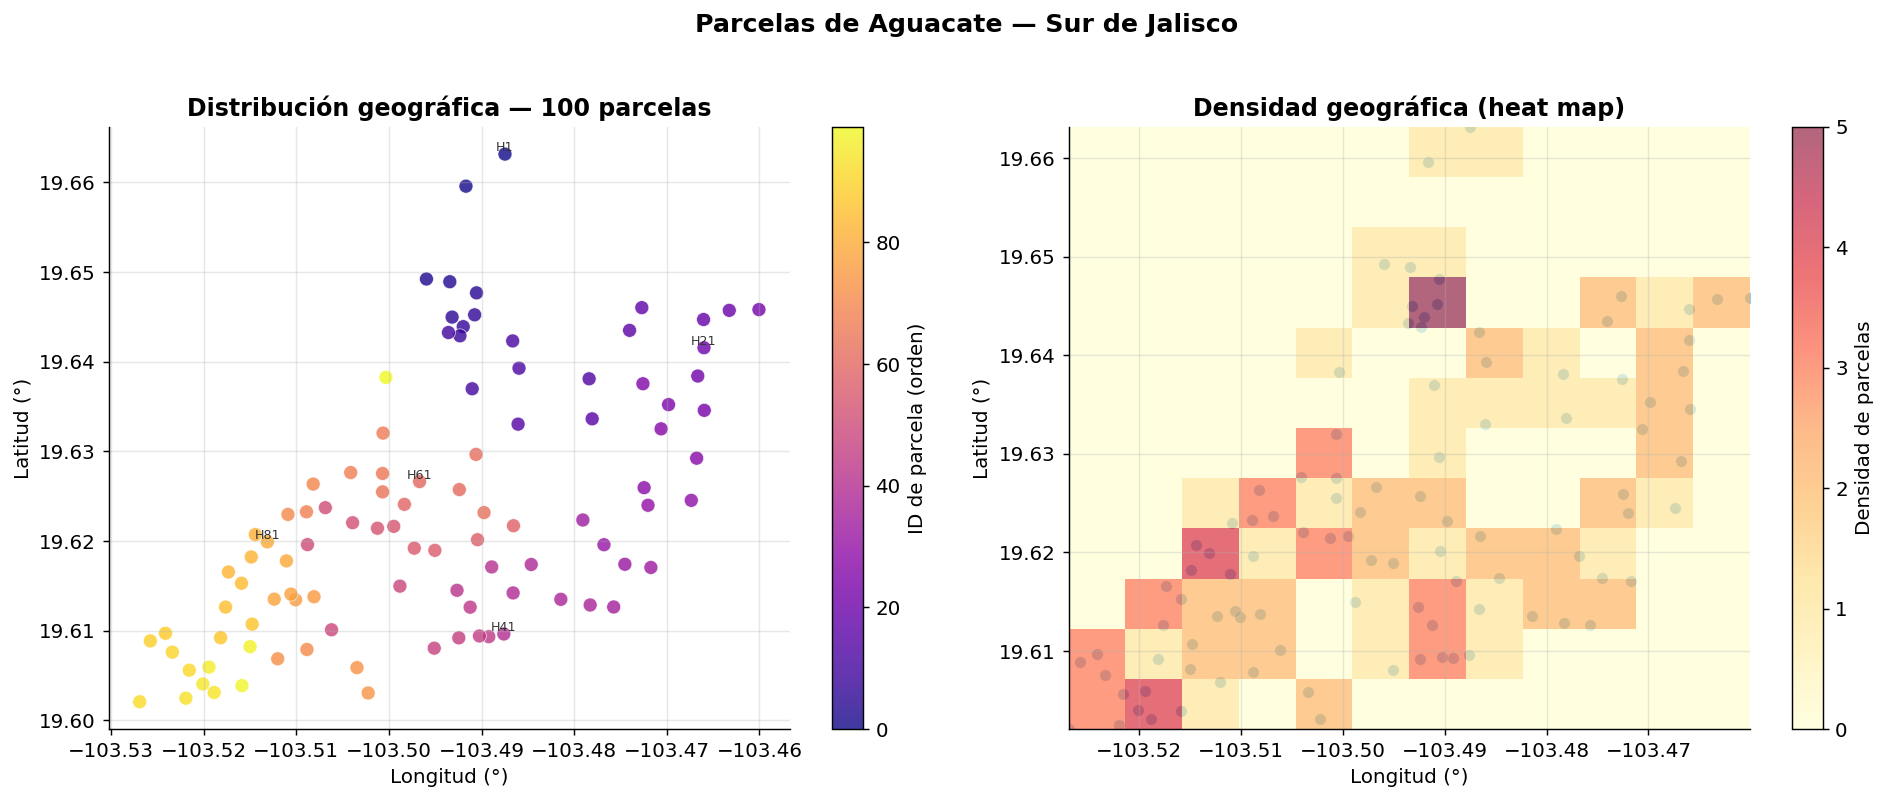


Área aproximada cubierta:
  7.0 km (EW) × 6.8 km (NS)
  ≈ 48 km²


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Mapa de dispersión de parcelas ─────────────────────────────────────────
ax = axes[0]
scatter = ax.scatter(
    df.longitude, df.latitude,
    c=range(len(df)), cmap="plasma",
    s=60, alpha=0.8, edgecolors="white", linewidths=0.4,
)
# Bbox del área total
lon_c = (df.longitude.min() + df.longitude.max()) / 2
lat_c = (df.latitude.min()  + df.latitude.max())  / 2

ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title(f"Distribución geográfica — {len(df)} parcelas", fontweight="bold")
plt.colorbar(scatter, ax=ax, label="ID de parcela (orden)")

# Añadir algunos IDs de referencia
for _, row in df.iloc[::20].iterrows():
    ax.annotate(row.parcel_id,
                (row.longitude, row.latitude),
                fontsize=7, color="#333", ha="center", va="bottom")

# ── Distribución de densidad lat/lon ───────────────────────────────────────
ax2 = axes[1]
ax2.scatter(df.longitude, df.latitude,
            alpha=0.5, s=40, color="#3498DB", edgecolors="white", linewidths=0.3)

# KDE manual simple con histograma 2D
h = ax2.hist2d(df.longitude, df.latitude, bins=12,
               cmap="YlOrRd", alpha=0.6)
plt.colorbar(h[3], ax=ax2, label="Densidad de parcelas")
ax2.set_xlabel("Longitud (°)")
ax2.set_ylabel("Latitud (°)")
ax2.set_title("Densidad geográfica (heat map)", fontweight="bold")

plt.suptitle("Parcelas de Aguacate — Sur de Jalisco", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nÁrea aproximada cubierta:")
delta_lon_km = (df.longitude.max()-df.longitude.min()) * 111.32 * np.cos(np.radians(lat_c))
delta_lat_km = (df.latitude.max()-df.latitude.min()) * 111.32
print(f"  {delta_lon_km:.1f} km (EW) × {delta_lat_km:.1f} km (NS)")
print(f"  ≈ {delta_lon_km*delta_lat_km:.0f} km²")


=== Distancias entre parcelas (metros) ===
  Mínima  : 88 m
  Mediana : 2,791 m
  Máxima  : 8,524 m
  Media   : 2,973 m


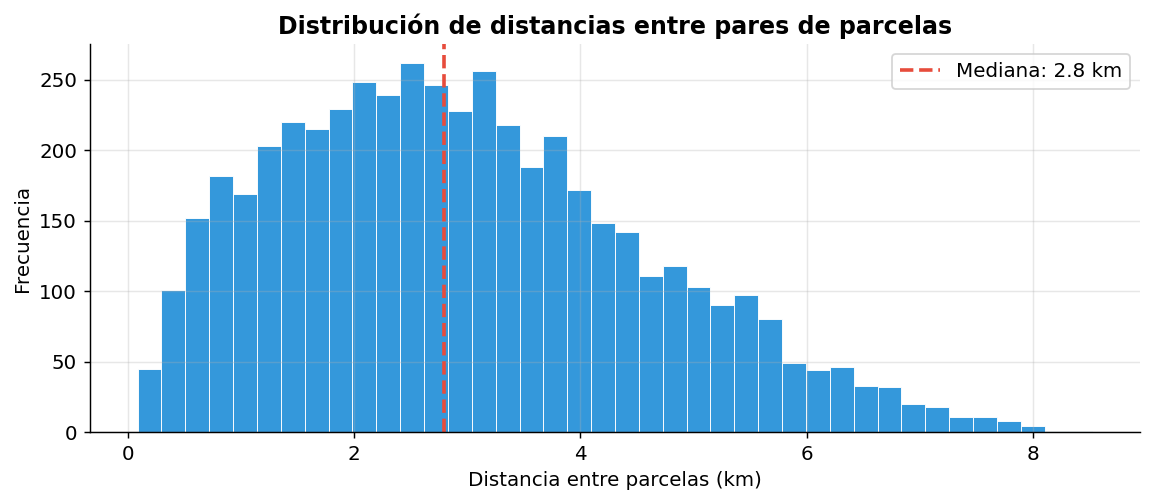

In [9]:
# ── Distancia entre parcelas ────────────────────────────────────────────────
from itertools import combinations

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi = np.radians([lat1, lat2])
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi[0])*np.cos(phi[1])*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a)) * 1000   # metros

dists = []
for (i, r1), (j, r2) in combinations(df.iterrows(), 2):
    dists.append(haversine(r1.latitude, r1.longitude, r2.latitude, r2.longitude))

dists = np.array(dists)
print("=== Distancias entre parcelas (metros) ===")
print(f"  Mínima  : {dists.min():,.0f} m")
print(f"  Mediana : {np.median(dists):,.0f} m")
print(f"  Máxima  : {dists.max():,.0f} m")
print(f"  Media   : {dists.mean():,.0f} m")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dists/1000, bins=40, color="#3498DB", edgecolor="white", linewidth=0.5)
ax.axvline(np.median(dists)/1000, color="#E74C3C", lw=2, ls="--",
           label=f"Mediana: {np.median(dists)/1000:.1f} km")
ax.set_xlabel("Distancia entre parcelas (km)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de distancias entre pares de parcelas", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## 3. Cobertura Temporal — ¿Cuántas imágenes disponibles por parcela?

> ⚠️ **Datos sintéticos** — Simulan la cobertura temporal esperada de Sentinel-2
> para la zona sur de Jalisco (2020-2026), considerando:
> - Revisita nominal de ~5 días
> - Filtro de nubosidad ≤ 20%
> - Temporada de lluvias (jun-oct) con menor disponibilidad


In [10]:
np.random.seed(42)

# Simular fechas disponibles por parcela
# Épocas: seca (nov-may) ~1 imagen / 7 días | lluvias (jun-oct) ~1 imagen / 18 días
def simulate_dates(parcel_id, seed=None):
    rng = np.random.default_rng(seed)
    dates = []
    start = datetime(2020, 1, 1)
    end   = datetime(2026, 5, 30)
    current = start
    while current < end:
        month = current.month
        # Temporada de lluvias: espaciado mayor
        if 6 <= month <= 10:
            gap = int(rng.integers(10, 28))
        else:
            gap = int(rng.integers(4, 14))
        current += timedelta(days=gap)
        if current < end:
            dates.append(current)
    return dates

temporal_data = {}
for i, row in df.iterrows():
    temporal_data[row.parcel_id] = simulate_dates(row.parcel_id, seed=i)

n_dates = {pid: len(d) for pid, d in temporal_data.items()}
dates_series = pd.Series(n_dates)

print("=== Cobertura temporal por parcela ===")
print(f"Imágenes por parcela:")
print(f"  Mínimo  : {dates_series.min()}")
print(f"  Máximo  : {dates_series.max()}")
print(f"  Mediana : {dates_series.median():.0f}")
print(f"  Media   : {dates_series.mean():.1f}")
print(f"\nTotal imágenes (100 parcelas): {dates_series.sum():,}")
print(f"Imágenes válidas (≥12 fechas): {(dates_series >= 12).sum()}/100")


=== Cobertura temporal por parcela ===
Imágenes por parcela:
  Mínimo  : 201
  Máximo  : 227
  Mediana : 214
  Media   : 213.5

Total imágenes (100 parcelas): 21,353
Imágenes válidas (≥12 fechas): 100/100


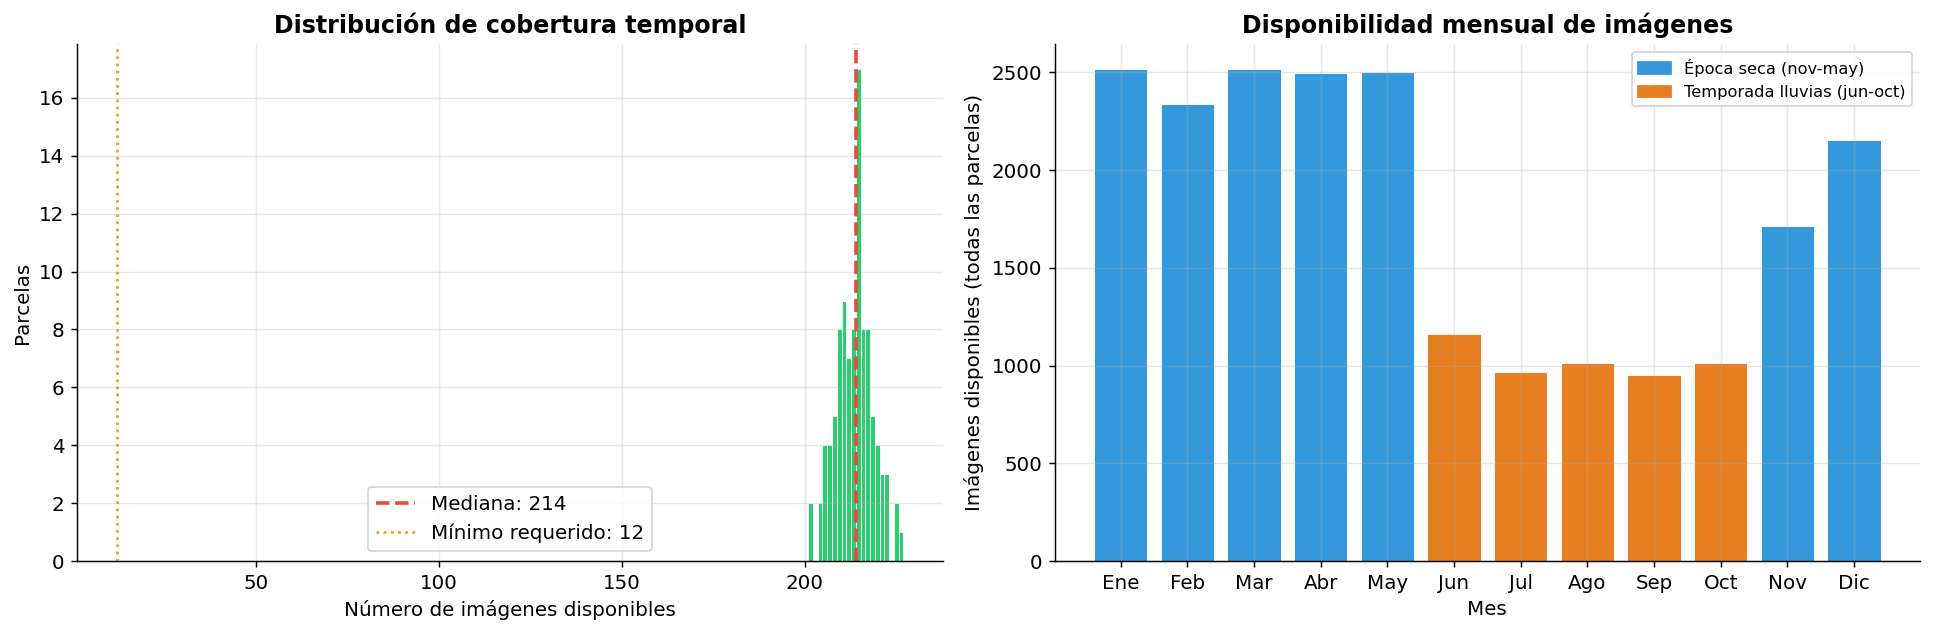

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Histograma de imágenes por parcela ─────────────────────────────────────
ax = axes[0]
ax.hist(dates_series.values, bins=20, color="#2ECC71", edgecolor="white", linewidth=0.5)
ax.axvline(dates_series.median(), color="#E74C3C", lw=2, ls="--",
           label=f"Mediana: {dates_series.median():.0f}")
ax.axvline(12, color="#F39C12", lw=1.5, ls=":",
           label="Mínimo requerido: 12")
ax.set_xlabel("Número de imágenes disponibles")
ax.set_ylabel("Parcelas")
ax.set_title("Distribución de cobertura temporal", fontweight="bold")
ax.legend()

# ── Disponibilidad mensual agregada ────────────────────────────────────────
ax2 = axes[1]
all_dates = [d for dates in temporal_data.values() for d in dates]
monthly   = pd.Series([d.month for d in all_dates])
month_names = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

counts = monthly.value_counts().sort_index()
bars   = ax2.bar(counts.index, counts.values,
                 color=["#3498DB" if m not in range(6,11) else "#E67E22"
                        for m in counts.index],
                 edgecolor="white", linewidth=0.5)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(month_names)
ax2.set_xlabel("Mes")
ax2.set_ylabel("Imágenes disponibles (todas las parcelas)")
ax2.set_title("Disponibilidad mensual de imágenes", fontweight="bold")

# Leyenda de temporadas
dry_patch   = mpatches.Patch(color="#3498DB",  label="Época seca (nov-may)")
rain_patch  = mpatches.Patch(color="#E67E22",  label="Temporada lluvias (jun-oct)")
ax2.legend(handles=[dry_patch, rain_patch], fontsize=9)

plt.tight_layout()
plt.show()


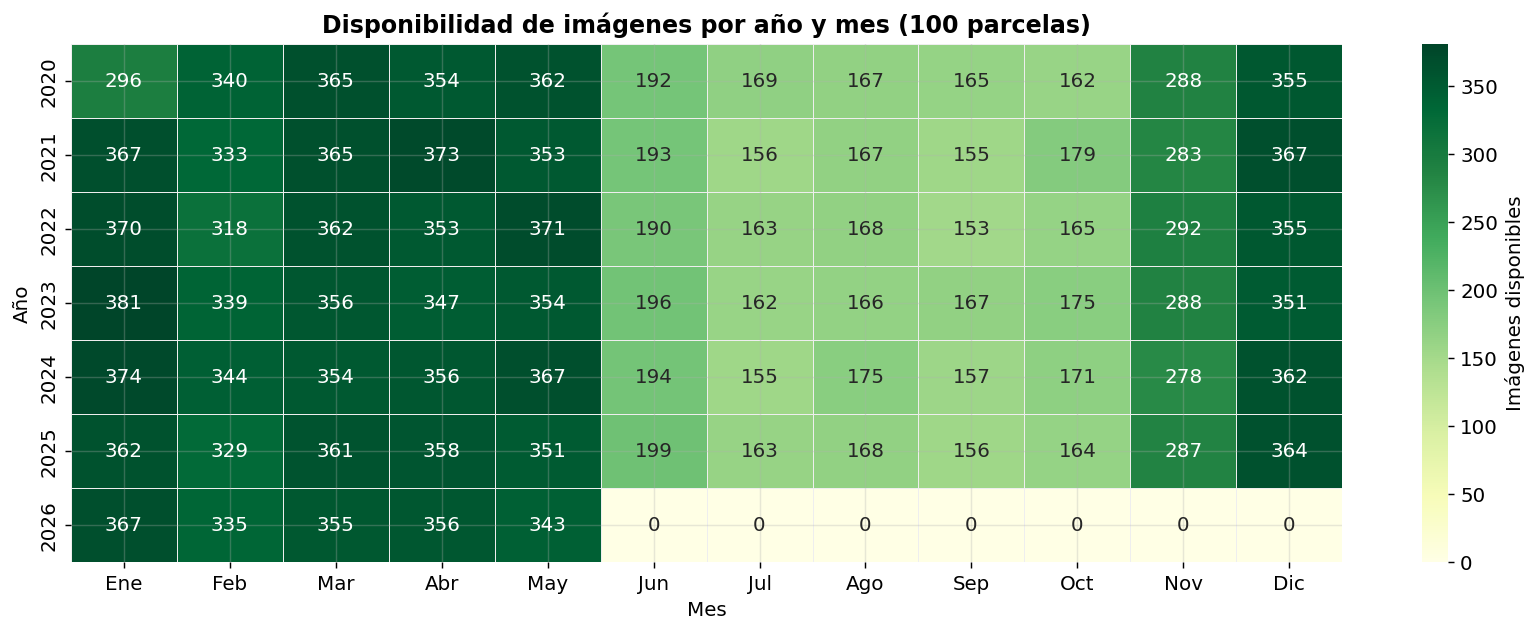

In [12]:
# ── Heatmap de disponibilidad por año/mes ──────────────────────────────────
pivot = pd.DataFrame([
    {"year": d.year, "month": d.month}
    for d in all_dates
]).groupby(["year","month"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    pivot, cmap="YlGn", annot=True, fmt="d",
    linewidths=0.5, linecolor="#eee",
    cbar_kws={"label": "Imágenes disponibles"},
    ax=ax
)
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
ax.set_xticklabels(month_names, rotation=0)
ax.set_title("Disponibilidad de imágenes por año y mes (100 parcelas)", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 4. Índices Espectrales — Distribución de NDVI / NDWI / NDMI / NDRE / EVI

> ⚠️ **Datos sintéticos** — Basados en valores de referencia para aguacate en
> condiciones de Jalisco reportados en la literatura:
>
> | Índice | Rango típico (sano) | Umbral de estrés |
> |--------|--------------------|--------------------|
> | NDVI   | 0.4 – 0.8          | < 0.35             |
> | NDWI   | -0.3 – 0.1         | < -0.3             |
> | NDMI   | -0.1 – 0.4  ★      | < -0.1             |
> | NDRE   | 0.2 – 0.6   ★      | < 0.15             |
> | EVI    | 0.2 – 0.6          | < 0.2              |
>
> ★ Más directos para estrés hídrico.


In [14]:
# Simular distribución de índices con parámetros realistas para aguacate
np.random.seed(0)
N = 5000   # muestras simuladas

index_params = {
    # (media, std, clip_min, clip_max)
    "NDVI": (0.58, 0.12, 0.0,  0.9),
    "NDWI": (-0.12, 0.15, -0.6, 0.3),
    "NDMI": (0.12,  0.18, -0.5, 0.6),
    "NDRE": (0.35,  0.14, -0.1, 0.7),
    "EVI":  (0.42,  0.13, 0.0,  0.8),
}

# Mezcla bimodal: 80% sano, 20% con estrés
stressed_shift = {"NDVI": -0.25, "NDWI": -0.25, "NDMI": -0.30, "NDRE": -0.20, "EVI": -0.20}

def simulate_index(name, n=N):
    mu, sigma, vmin, vmax = index_params[name]
    shift = stressed_shift[name]
    n_stressed = int(n * 0.20)
    n_healthy  = n - n_stressed
    healthy  = np.random.normal(mu, sigma, n_healthy)
    stressed = np.random.normal(mu + shift, sigma * 0.8, n_stressed)
    return np.clip(np.concatenate([healthy, stressed]), vmin, vmax).astype(np.float32)

index_data = {name: simulate_index(name) for name in INDICES}
print("Estadísticas de índices (muestra sintética):")
for name, vals in index_data.items():
    print(f"  {name:5s}: mean={vals.mean():.3f}  std={vals.std():.3f}  "
          f"min={vals.min():.3f}  max={vals.max():.3f}")


Estadísticas de índices (muestra sintética):
  NDVI : mean=0.528  std=0.150  min=0.041  max=0.900
  NDWI : mean=-0.173  std=0.173  min=-0.600  max=0.300
  NDMI : mean=0.060  std=0.208  min=-0.500  max=0.600
  NDRE : mean=0.312  std=0.154  min=-0.100  max=0.700
  EVI  : mean=0.381  std=0.148  min=0.000  max=0.800


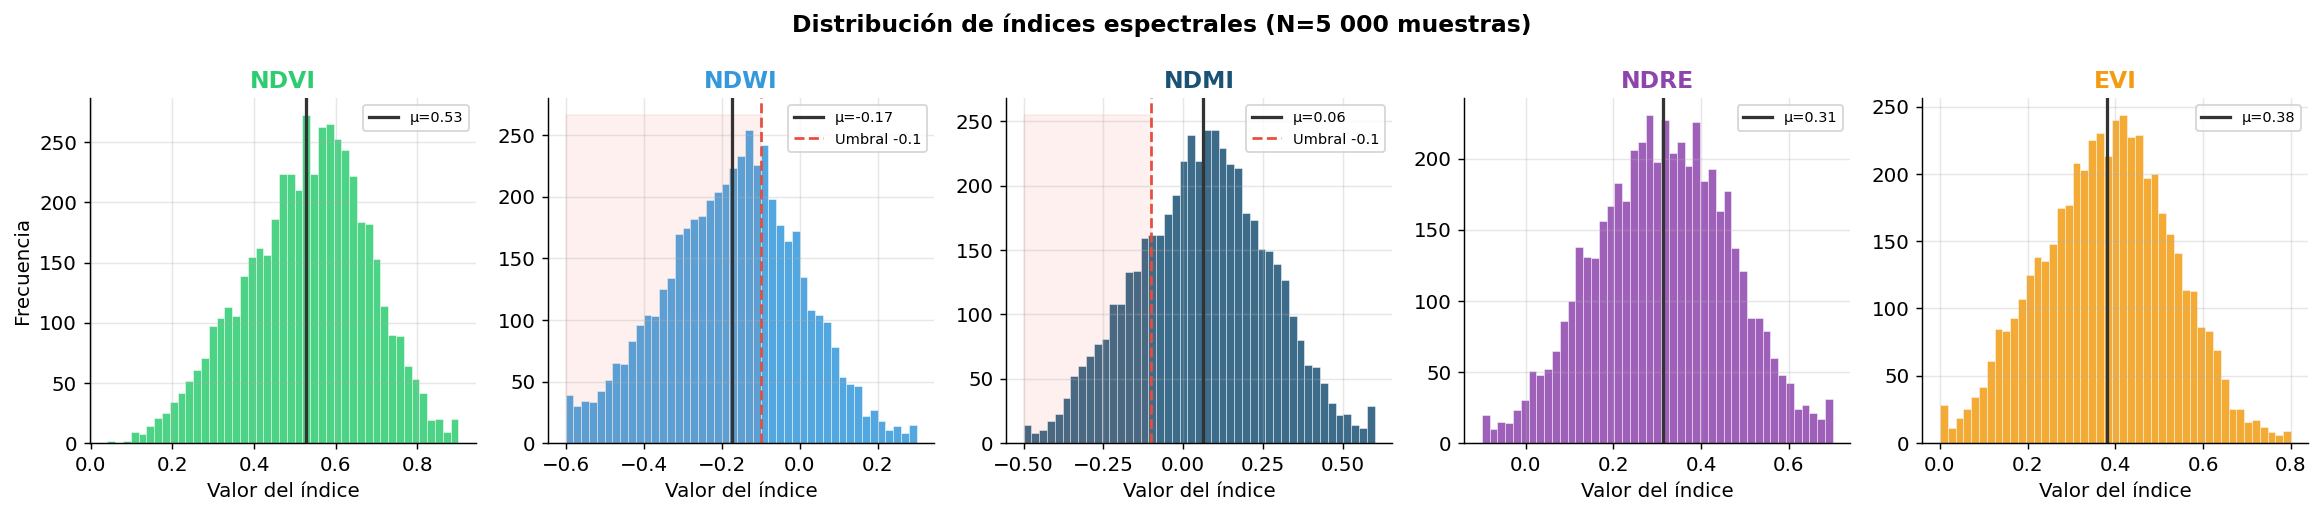

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (name, vals) in zip(axes, index_data.items()):
    color = INDEX_COLORS[name]
    ax.hist(vals, bins=45, color=color, alpha=0.85, edgecolor="white", linewidth=0.3)

    # Línea de media
    ax.axvline(vals.mean(), color="#333", lw=1.8, ls="-",
               label=f"μ={vals.mean():.2f}")

    # Umbral de estrés para NDMI y NDRE
    if name in ("NDMI", "NDWI"):
        ax.axvline(NDMI_THRESHOLD, color="#E74C3C", lw=1.5, ls="--",
                   label=f"Umbral {NDMI_THRESHOLD}")
        ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 200],
                         vals.min(), NDMI_THRESHOLD,
                         color="#E74C3C", alpha=0.08)

    ax.set_title(name, fontweight="bold", color=color, fontsize=13)
    ax.set_xlabel("Valor del índice")
    ax.legend(fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel("Frecuencia")

plt.suptitle("Distribución de índices espectrales (N=5 000 muestras)", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


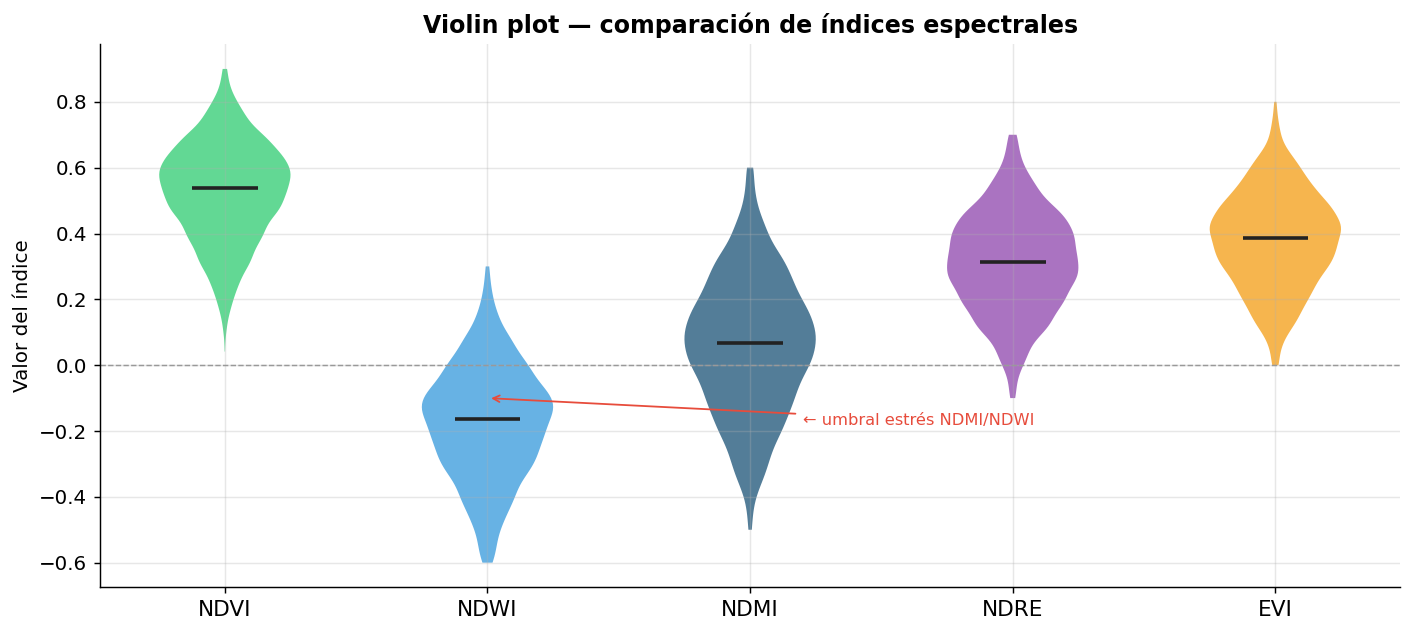

In [16]:
# ── Boxplot comparativo ─────────────────────────────────────────────────────
df_idx = pd.DataFrame(index_data)

fig, ax = plt.subplots(figsize=(11, 5))
parts = ax.violinplot(
    [df_idx[c].values for c in INDICES],
    positions=range(len(INDICES)),
    showmedians=True, showextrema=False,
)
for i, (pc, name) in enumerate(zip(parts["bodies"], INDICES)):
    pc.set_facecolor(INDEX_COLORS[name])
    pc.set_alpha(0.75)

parts["cmedians"].set_color("#222")
parts["cmedians"].set_linewidth(2)

ax.set_xticks(range(len(INDICES)))
ax.set_xticklabels(INDICES, fontsize=12)
ax.set_ylabel("Valor del índice")
ax.set_title("Violin plot — comparación de índices espectrales", fontweight="bold")
ax.axhline(0, color="#999", lw=0.8, ls="--")

# Umbral NDMI/NDWI
ax.annotate("← umbral estrés NDMI/NDWI",
            xy=(1, NDMI_THRESHOLD), fontsize=9, color="#E74C3C",
            xytext=(2.2, NDMI_THRESHOLD - 0.08),
            arrowprops=dict(arrowstyle="->", color="#E74C3C"))

plt.tight_layout()
plt.show()


---
## 5. Estrés Hídrico — ¿Cuántas parcelas muestran señal de estrés?

Se usa **NDMI < -0.1** como proxy de estrés hídrico (umbral configurable).
Este umbral se reemplazará por etiquetas de campo cuando estén disponibles.


In [17]:
# Simular NDMI medio por parcela (incorpora variabilidad entre parcelas)
np.random.seed(7)
# 25% de parcelas con estrés, 75% sanas
n_stressed_parcels = 25
ndmi_per_parcel = np.concatenate([
    np.random.normal(-0.22, 0.08, n_stressed_parcels),   # estresadas
    np.random.normal(0.18,  0.10, 100 - n_stressed_parcels),  # sanas
])
np.random.shuffle(ndmi_per_parcel)

df["ndmi_mean"]  = ndmi_per_parcel
df["is_stressed"] = df["ndmi_mean"] < NDMI_THRESHOLD

n_str  = df["is_stressed"].sum()
n_heal = (~df["is_stressed"]).sum()
pct_str = n_str / len(df) * 100

print(f"Parcelas sanas    : {n_heal} ({100-pct_str:.1f}%)")
print(f"Parcelas estresadas: {n_str} ({pct_str:.1f}%)")
print(f"\nNDMI medio — estresadas: {df[df.is_stressed].ndmi_mean.mean():.3f}")
print(f"NDMI medio — sanas     : {df[~df.is_stressed].ndmi_mean.mean():.3f}")


Parcelas sanas    : 78 (78.0%)
Parcelas estresadas: 22 (22.0%)

NDMI medio — estresadas: -0.235
NDMI medio — sanas     : 0.170


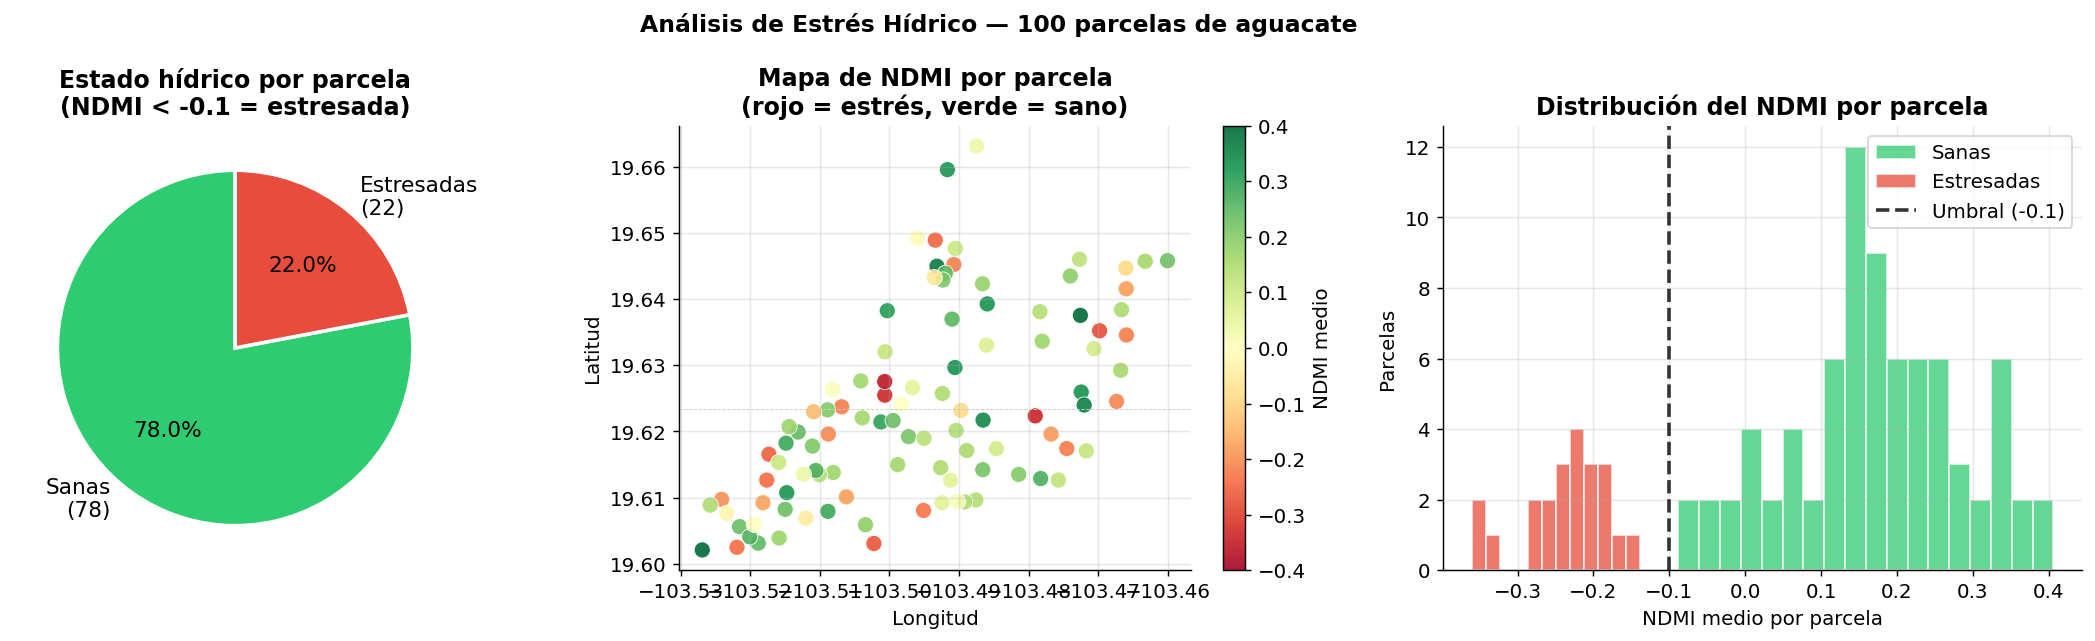

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Pie de distribución ─────────────────────────────────────────────────────
ax = axes[0]
ax.pie(
    [n_heal, n_str],
    labels=[f"Sanas\n({n_heal})", f"Estresadas\n({n_str})"],
    colors=["#2ECC71", "#E74C3C"],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12},
)
ax.set_title("Estado hídrico por parcela\n(NDMI < -0.1 = estresada)", fontweight="bold")

# ── Mapa de calor geográfico ────────────────────────────────────────────────
ax2 = axes[1]
scatter = ax2.scatter(
    df.longitude, df.latitude,
    c=df["ndmi_mean"],
    cmap="RdYlGn", vmin=-0.4, vmax=0.4,
    s=80, alpha=0.9, edgecolors="white", linewidths=0.5,
)
ax2.axhline(y=df.latitude.mean(), color="#ccc", lw=0.5, ls="--")
plt.colorbar(scatter, ax=ax2, label="NDMI medio")
ax2.set_xlabel("Longitud")
ax2.set_ylabel("Latitud")
ax2.set_title("Mapa de NDMI por parcela\n(rojo = estrés, verde = sano)", fontweight="bold")

# ── Distribución del NDMI medio por parcela ─────────────────────────────────
ax3 = axes[2]
ax3.hist(df[~df.is_stressed]["ndmi_mean"], bins=18,
         color="#2ECC71", alpha=0.75, label="Sanas", edgecolor="white")
ax3.hist(df[df.is_stressed]["ndmi_mean"], bins=12,
         color="#E74C3C", alpha=0.75, label="Estresadas", edgecolor="white")
ax3.axvline(NDMI_THRESHOLD, color="#333", lw=2, ls="--",
            label=f"Umbral ({NDMI_THRESHOLD})")
ax3.set_xlabel("NDMI medio por parcela")
ax3.set_ylabel("Parcelas")
ax3.set_title("Distribución del NDMI por parcela", fontweight="bold")
ax3.legend()

plt.suptitle("Análisis de Estrés Hídrico — 100 parcelas de aguacate", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 6. Series de Tiempo — Evolución temporal de los índices

Visualizamos cómo cambian los índices a lo largo del año para mostrar:
- La **estacionalidad** anual (época seca vs lluviosa)
- La **señal de estrés** en distintas fases fenológicas del aguacate


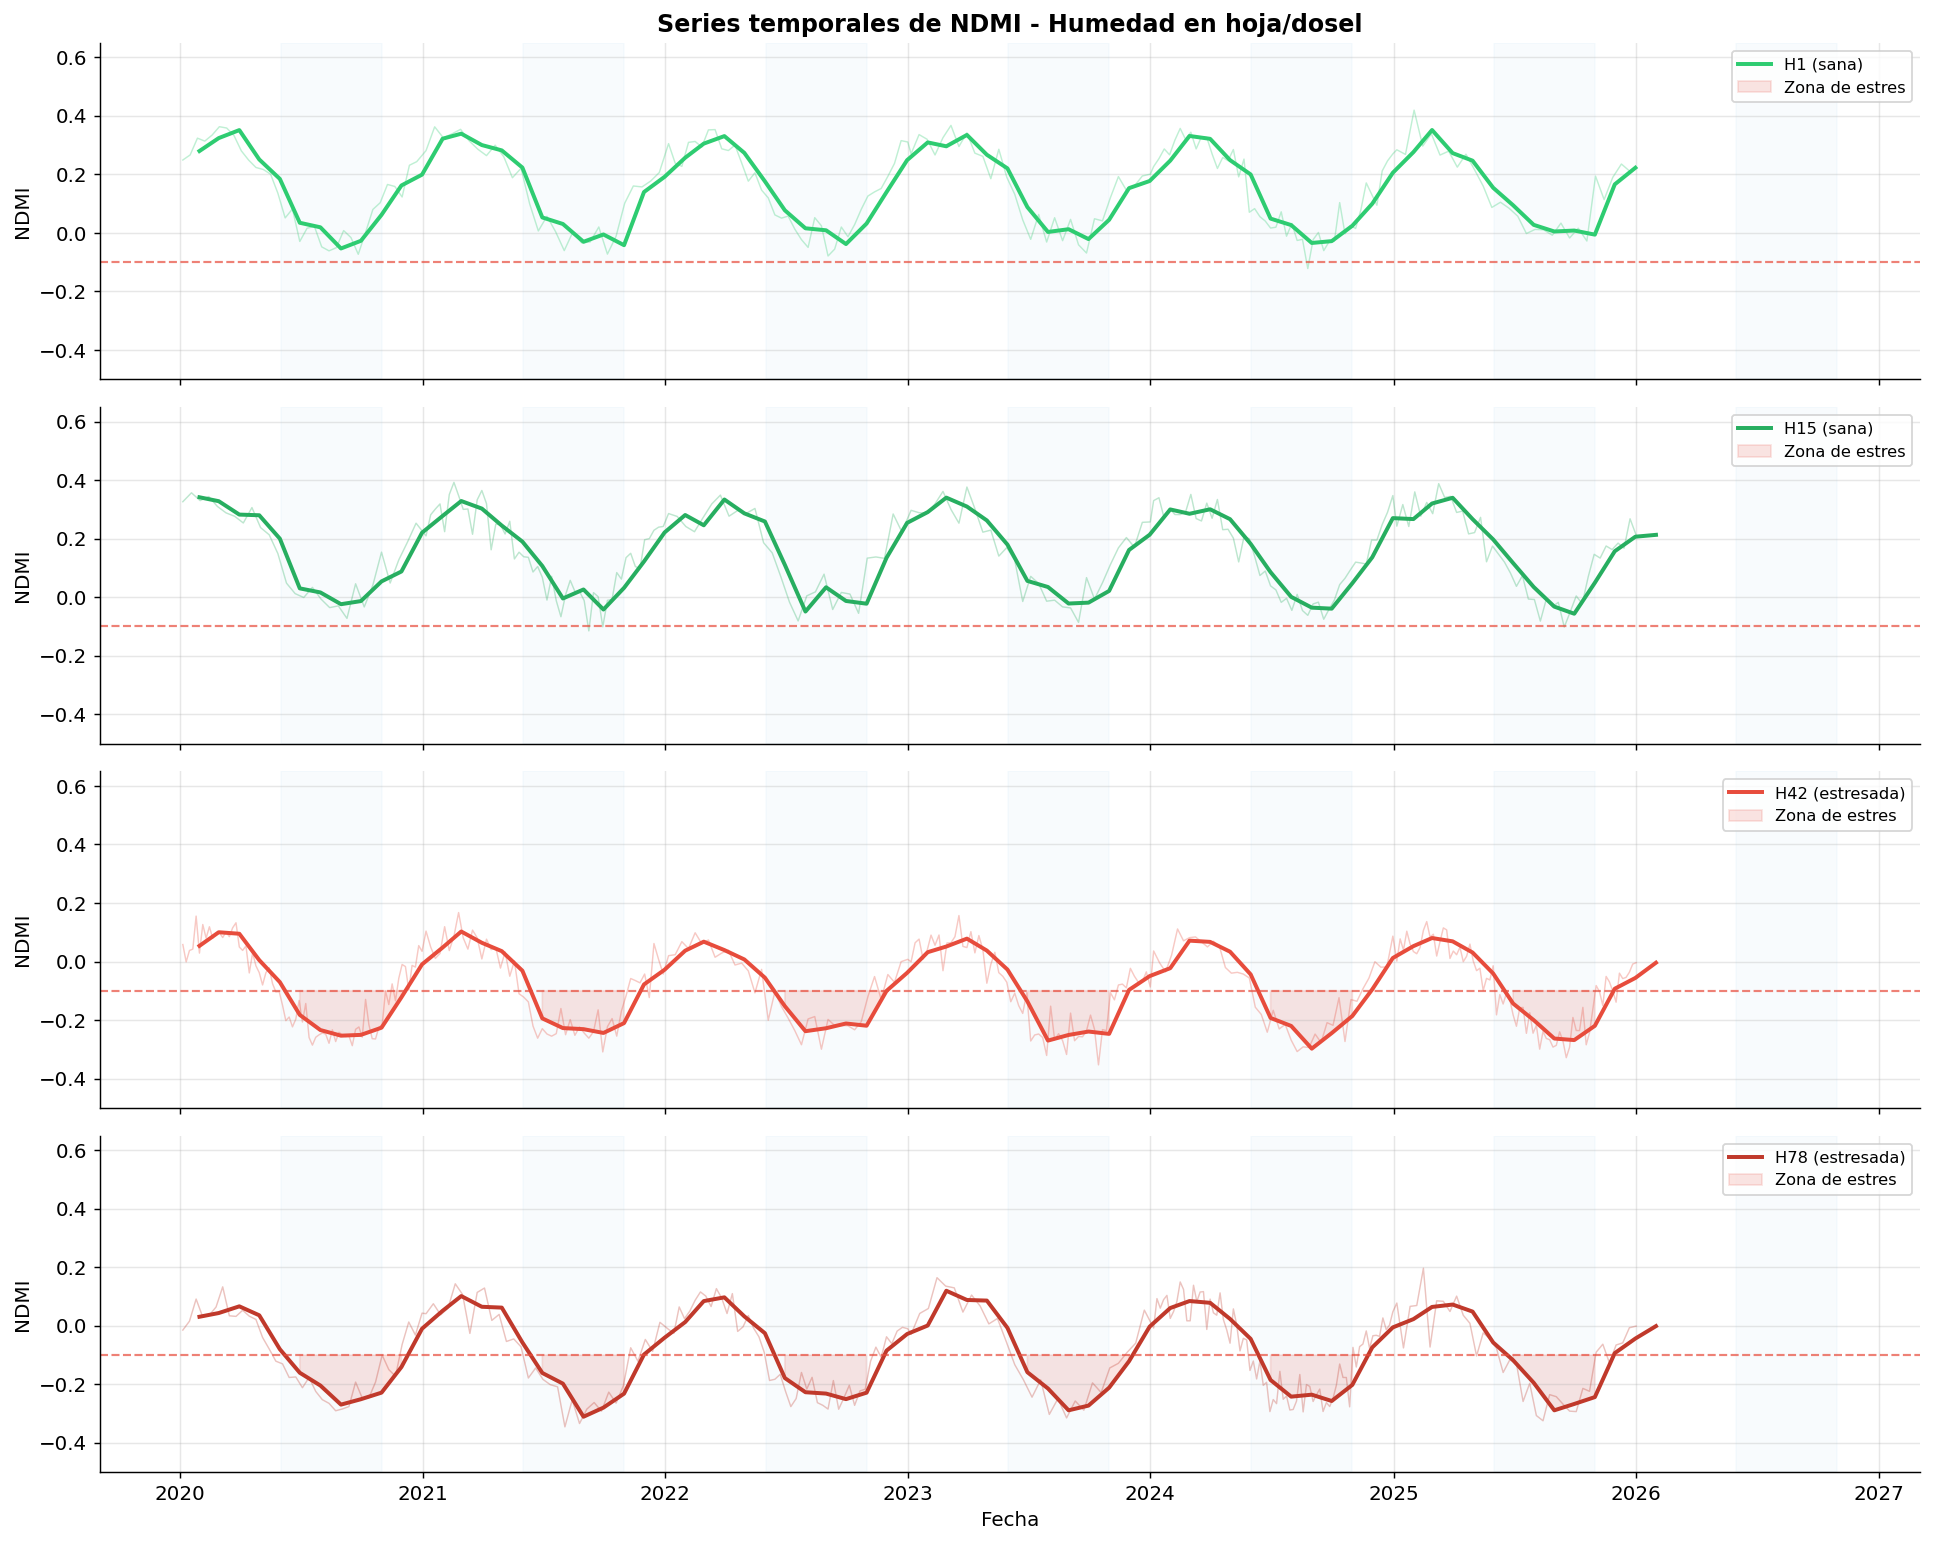

In [19]:
# Simular serie temporal de indices para varias parcelas
def simulate_ts(parcel_id, n_years=6, stressed=False, seed=0):
    rng = np.random.default_rng(seed)
    dates, values = [], []
    base   = datetime(2020, 1, 1)
    shift  = -0.25 if stressed else 0.0

    for year in range(n_years):
        for doy in range(5, 366, int(rng.integers(5, 14))):
            date = base.replace(year=2020+year) + timedelta(days=doy)
            if date > datetime(2026, 5, 30): break
            angle = 2 * np.pi * doy / 365
            seasonal     = 0.15 * np.cos(angle - np.pi * 0.3)
            noise        = rng.normal(0, 0.04)
            rain_penalty = -0.05 if 6 <= date.month <= 10 else 0
            ndmi_val     = 0.18 + shift + seasonal + rain_penalty + noise
            ndmi_val     = np.clip(ndmi_val, -0.5, 0.6)
            dates.append(date)
            values.append(ndmi_val)

    return pd.DataFrame({"date": dates, "NDMI": values}).set_index("date")

ts_examples = {
    "H1 (sana)"      : simulate_ts("H1",  stressed=False, seed=10),
    "H15 (sana)"     : simulate_ts("H15", stressed=False, seed=20),
    "H42 (estresada)": simulate_ts("H42", stressed=True,  seed=30),
    "H78 (estresada)": simulate_ts("H78", stressed=True,  seed=40),
}

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
colors_ts = ["#2ECC71","#27AE60","#E74C3C","#C0392B"]

for ax, (label, ts), color in zip(axes, ts_examples.items(), colors_ts):
    monthly = ts["NDMI"].resample("ME").mean()
    ax.plot(ts.index, ts["NDMI"], color=color, alpha=0.3, lw=0.8)
    ax.plot(monthly.index, monthly.values, color=color, lw=2.2, label=label)
    ax.axhline(NDMI_THRESHOLD, color="#E74C3C", lw=1.2, ls="--", alpha=0.7)
    ax.fill_between(monthly.index, monthly.values, NDMI_THRESHOLD,
                    where=(monthly.values < NDMI_THRESHOLD),
                    color="#E74C3C", alpha=0.15, label="Zona de estres")
    ax.set_ylabel("NDMI")
    ax.set_ylim(-0.5, 0.65)
    ax.legend(loc="upper right", fontsize=9)
    for year in range(2020, 2027):
        ax.axvspan(datetime(year,6,1), datetime(year,10,31),
                   color="#AED6F1", alpha=0.08)

axes[0].set_title("Series temporales de NDMI - Humedad en hoja/dosel", fontweight="bold")
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

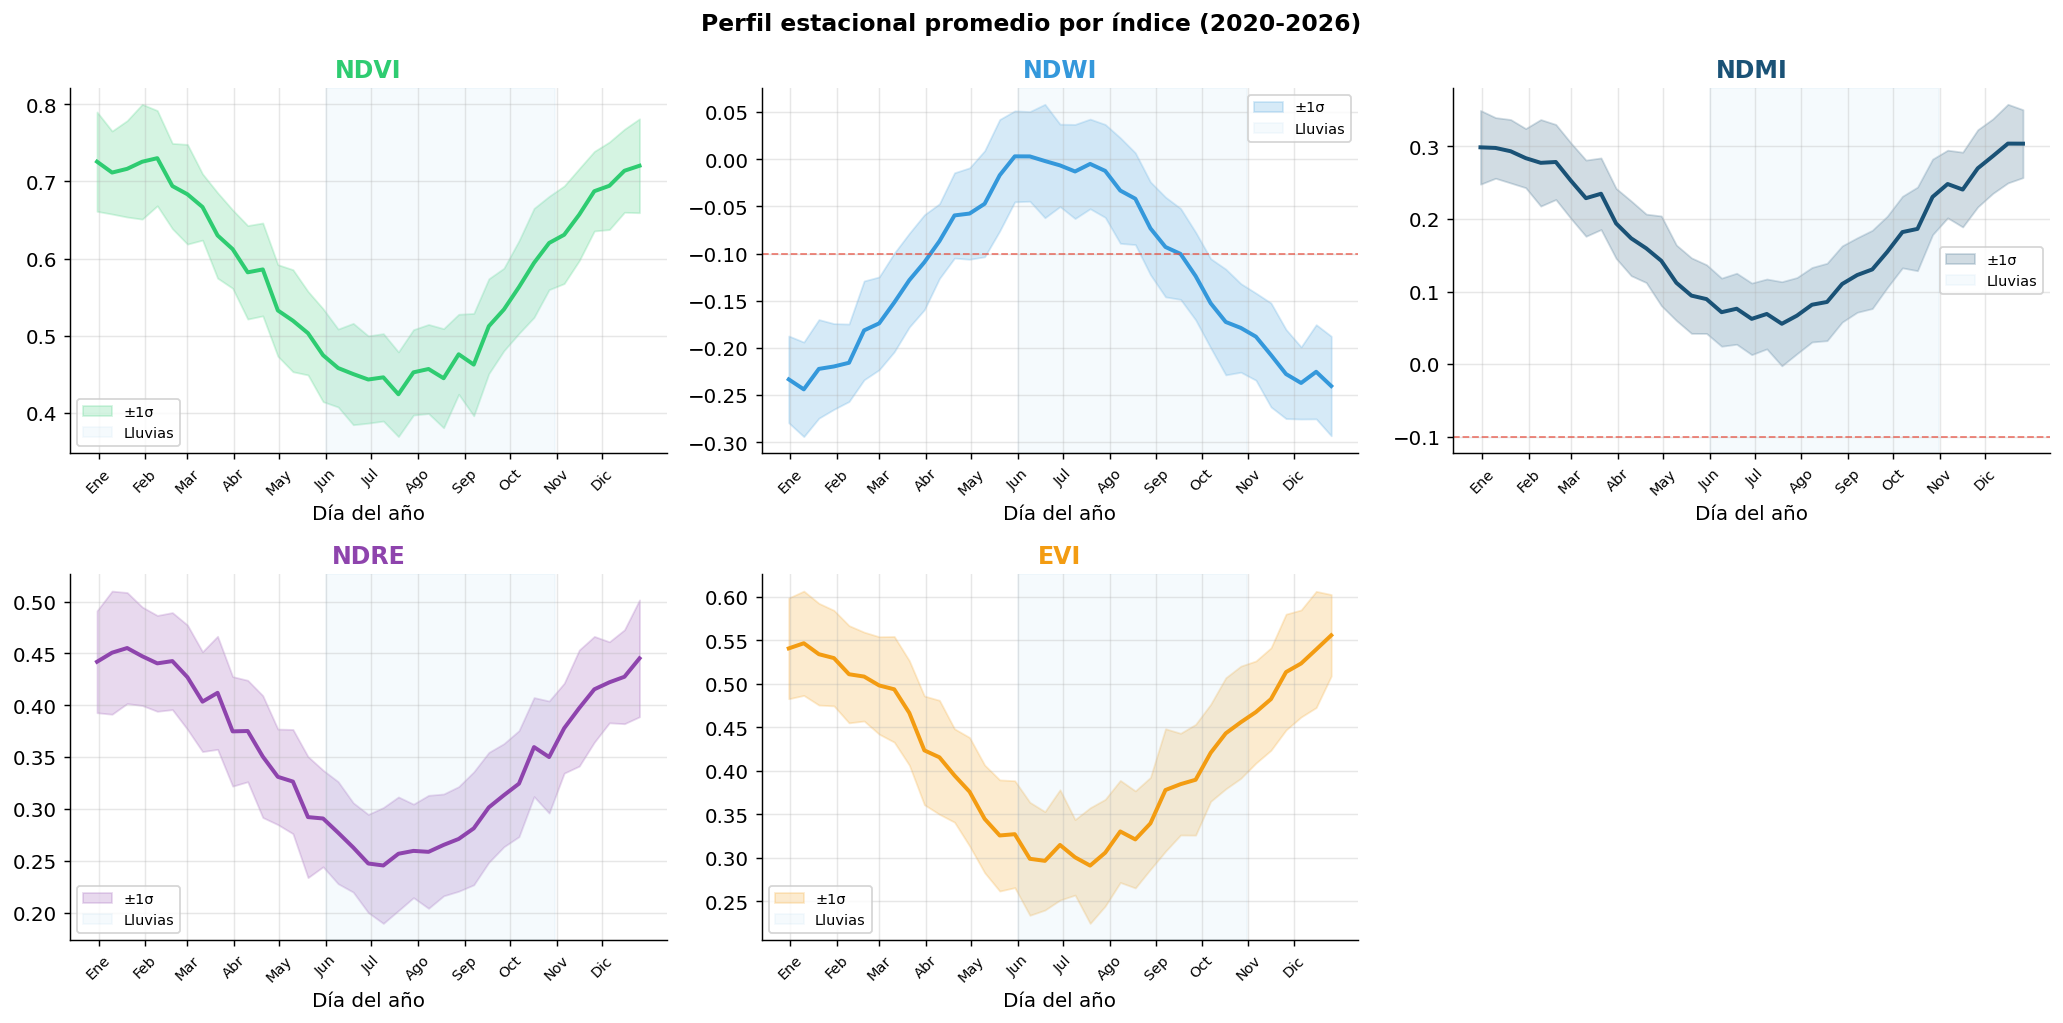

In [20]:
# ── Perfil estacional promedio (todos los índices) ──────────────────────────
def simulate_all_indices_by_doy(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    doys = rng.integers(1, 366, n)
    angles = 2 * np.pi * doys / 365
    rows = []
    for i, doy in enumerate(doys):
        a = angles[i]
        row = {
            "doy": doy,
            "NDVI": np.clip(0.58 + 0.15*np.cos(a-0.3) + rng.normal(0,0.06), 0, 1),
            "NDWI": np.clip(-0.12 - 0.12*np.cos(a) + rng.normal(0,0.05), -0.6, 0.4),
            "NDMI": np.clip(0.18 + 0.12*np.cos(a-0.2) + rng.normal(0,0.05), -0.5, 0.6),
            "NDRE": np.clip(0.35 + 0.10*np.cos(a-0.4) + rng.normal(0,0.05), -0.1, 0.8),
            "EVI":  np.clip(0.42 + 0.12*np.cos(a-0.2) + rng.normal(0,0.06), 0, 0.8),
        }
        rows.append(row)
    return pd.DataFrame(rows)

doy_df = simulate_all_indices_by_doy()
doy_df["doy_bin"] = (doy_df["doy"] // 10) * 10   # bins de 10 días

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
month_ticks = [1,32,60,91,121,152,182,213,244,274,305,335]
month_labels = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

for ax, name in zip(axes, INDICES):
    grp = doy_df.groupby("doy_bin")[name]
    mu  = grp.mean()
    sd  = grp.std()
    ax.plot(mu.index, mu.values, color=INDEX_COLORS[name], lw=2.2)
    ax.fill_between(mu.index, mu-sd, mu+sd,
                    color=INDEX_COLORS[name], alpha=0.2, label="±1σ")
    ax.set_title(name, fontweight="bold", color=INDEX_COLORS[name])
    ax.set_xlabel("Día del año")
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, fontsize=8, rotation=45)
    # Sombrear lluvias
    ax.axvspan(152, 304, color="#AED6F1", alpha=0.12, label="Lluvias")
    ax.legend(fontsize=8)
    if name in ("NDMI", "NDWI"):
        ax.axhline(NDMI_THRESHOLD, color="#E74C3C", lw=1, ls="--", alpha=0.7)

axes[-1].axis("off")   # celda vacía
plt.suptitle("Perfil estacional promedio por índice (2020-2026)", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 7. Correlaciones entre índices

Entender la correlación ayuda a:
- Detectar **redundancias** (índices que miden lo mismo → se podría reducir dimensionalidad)
- Confirmar **relaciones esperadas** (ej. NDVI y NDMI deberían correlacionar positivamente)


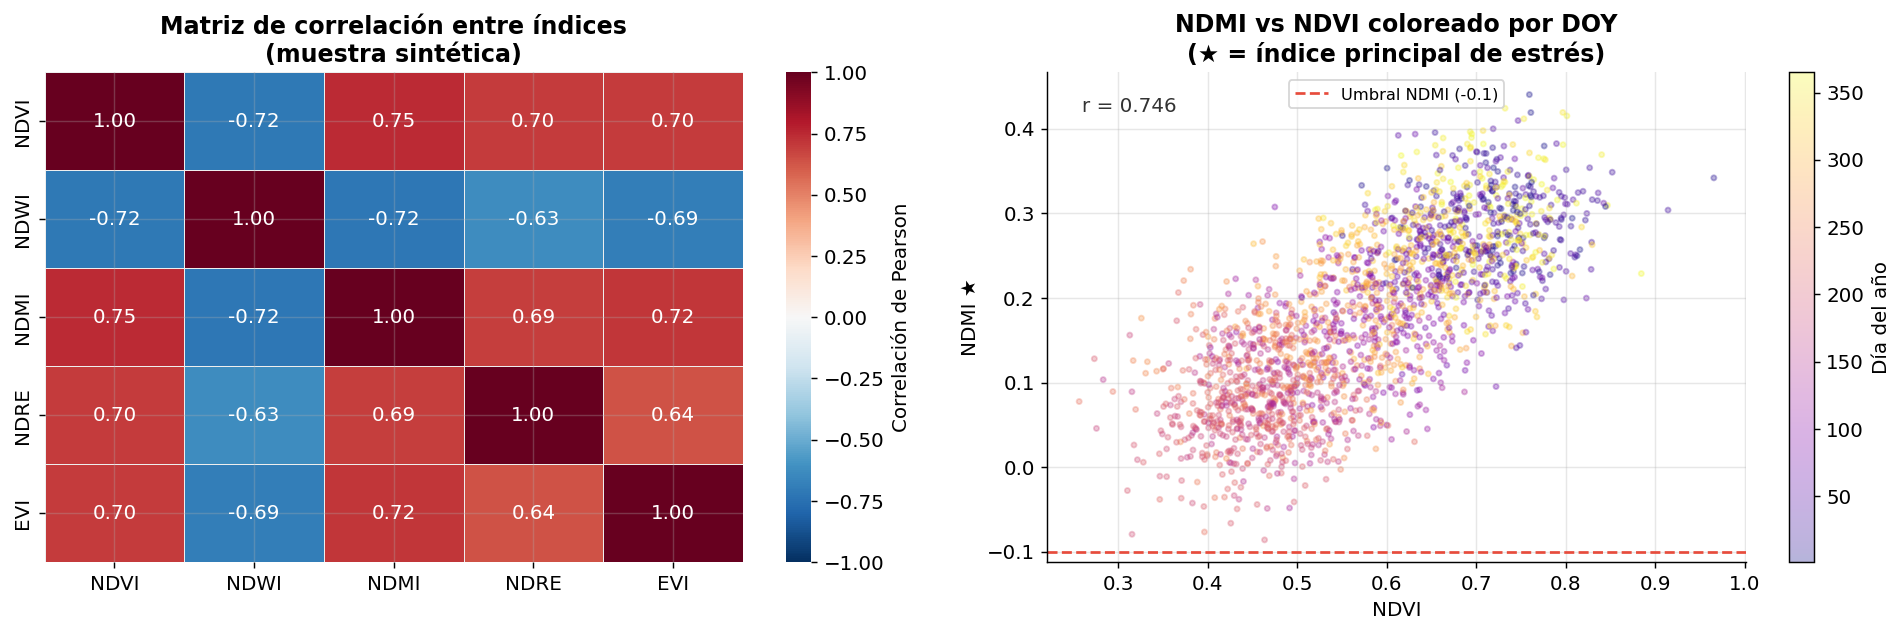


Correlaciones más altas:
  NDVI ↔ NDMI: r = 0.746
  NDWI ↔ NDMI: r = -0.725
  NDVI ↔ NDWI: r = -0.717
  NDMI ↔ EVI: r = 0.717
  NDVI ↔ EVI: r = 0.699


In [21]:
corr = doy_df[INDICES].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Heatmap de correlaciones ────────────────────────────────────────────────
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, linewidths=0.5, linecolor="#eee",
    cbar_kws={"label": "Correlación de Pearson"},
    ax=axes[0],
)
axes[0].set_title("Matriz de correlación entre índices\n(muestra sintética)", fontweight="bold")

# ── Scatter NDMI vs NDVI (los más importantes para el modelo) ──────────────
ax2 = axes[1]
sc = ax2.scatter(
    doy_df["NDVI"], doy_df["NDMI"],
    c=doy_df["doy"], cmap="plasma",
    alpha=0.3, s=8,
)
plt.colorbar(sc, ax=ax2, label="Día del año")
ax2.axhline(NDMI_THRESHOLD, color="#E74C3C", lw=1.5, ls="--",
            label=f"Umbral NDMI ({NDMI_THRESHOLD})")
ax2.set_xlabel("NDVI")
ax2.set_ylabel("NDMI ★")
ax2.set_title("NDMI vs NDVI coloreado por DOY\n(★ = índice principal de estrés)", 
              fontweight="bold")
ax2.legend(fontsize=9)

r = doy_df["NDVI"].corr(doy_df["NDMI"])
ax2.text(0.05, 0.92, f"r = {r:.3f}", transform=ax2.transAxes,
         fontsize=11, color="#333")

plt.tight_layout()
plt.show()

print("\nCorrelaciones más altas:")
corr_flat = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top = corr_flat.stack().abs().sort_values(ascending=False)
for (i,j), v in top.head(5).items():
    print(f"  {i} ↔ {j}: r = {corr.loc[i,j]:.3f}")


---
## 8. Calidad del Dataset

Verificamos el estado del split train/val/test y la calidad de los datos
disponibles para el entrenamiento de los modelos CNN y ViT.


In [22]:
# Estado del dataset (lo que ya está listo)
dataset_status = {
    "KML original (100 parcelas)":        True,
    "CSV de parcelas (parcelas.csv)":      PARCELS_CSV.exists(),
    "Imágenes Sentinel-2 descargadas":     (INDICES_DIR.parent.parent / "raw/sentinel2").exists(),
    "Índices calculados (NDVI...EVI)":     INDICES_DIR.exists(),
    "Dataset .npz (patches + signals)":   DATASETS_DIR.exists(),
    "split.json (train/val/test)":        (DATASETS_DIR / "split.json").exists(),
    "normalizer_stats.json":              (DATASETS_DIR / "normalizer_stats.json").exists(),
}

print("=== Estado actual del pipeline ===")
for step, ok in dataset_status.items():
    icon = "✅" if ok else "⏳"
    print(f"  {icon} {step}")

# Split simulado si no existe
import json
split_path = DATASETS_DIR / "split.json"
if split_path.exists():
    split = json.loads(split_path.read_text())
else:
    # Simular split 70/15/15
    rng = np.random.default_rng(42)
    ids = df["parcel_id"].tolist()
    rng.shuffle(ids)
    n = len(ids)
    split = {
        "train": ids[:70],
        "val":   ids[70:85],
        "test":  ids[85:],
    }

print(f"\n=== Split train/val/test ===")
for subset, ids in split.items():
    n_stressed_sub = df[df.parcel_id.isin(ids)]["is_stressed"].sum()
    pct = n_stressed_sub / len(ids) * 100
    print(f"  {subset:6s}: {len(ids):3d} parcelas | {n_stressed_sub} estresadas ({pct:.1f}%)")


=== Estado actual del pipeline ===
  ✅ KML original (100 parcelas)
  ✅ CSV de parcelas (parcelas.csv)
  ✅ Imágenes Sentinel-2 descargadas
  ⏳ Índices calculados (NDVI...EVI)
  ⏳ Dataset .npz (patches + signals)
  ⏳ split.json (train/val/test)
  ⏳ normalizer_stats.json

=== Split train/val/test ===
  train :  70 parcelas | 13 estresadas (18.6%)
  val   :  15 parcelas | 6 estresadas (40.0%)
  test  :  15 parcelas | 3 estresadas (20.0%)


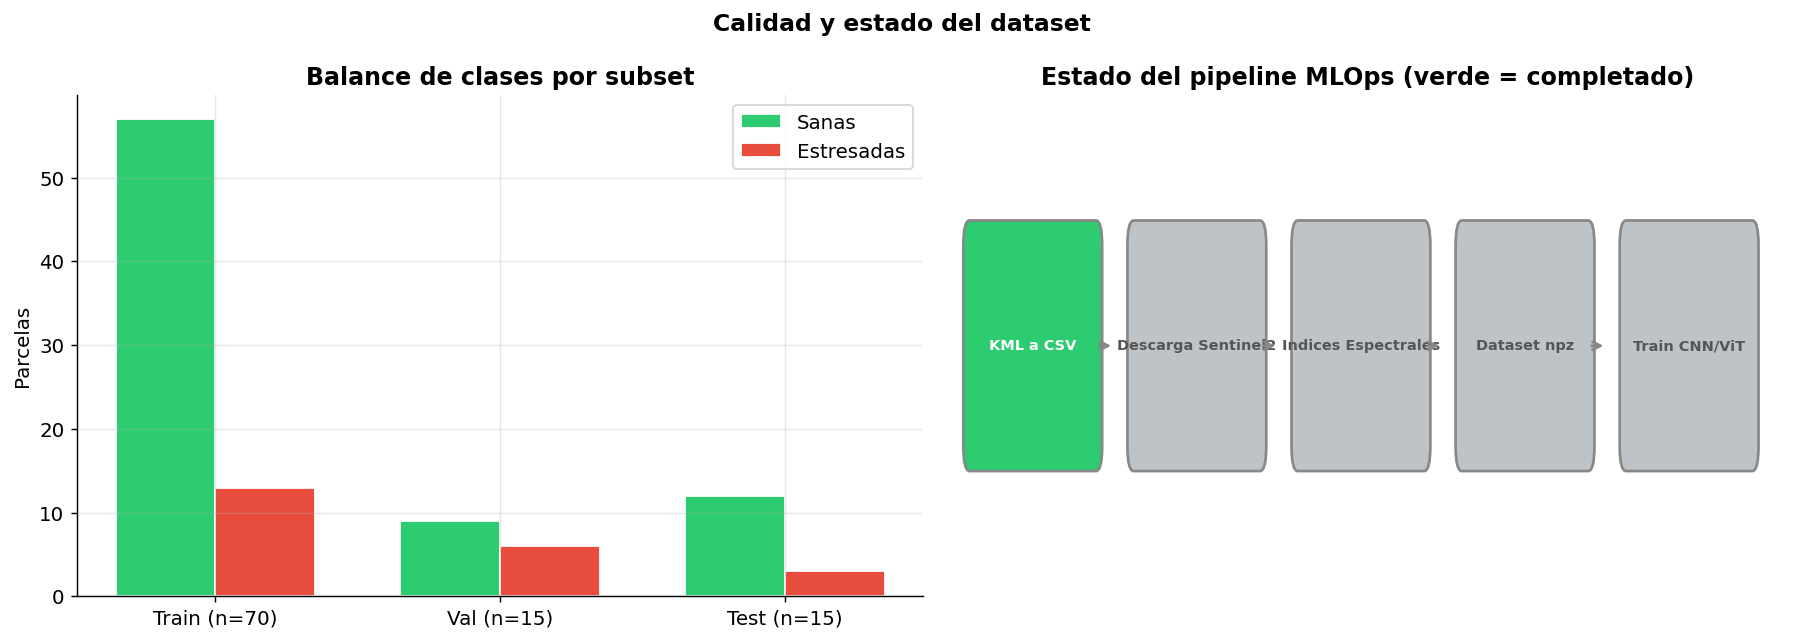

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
subsets   = list(split.keys())
sizes     = [len(v) for v in split.values()]
n_stress  = [df[df.parcel_id.isin(ids)]["is_stressed"].sum() for ids in split.values()]
n_healthy = [s - st for s, st in zip(sizes, n_stress)]

x = np.arange(len(subsets))
w = 0.35
ax.bar(x - w/2, n_healthy, w, label="Sanas",      color="#2ECC71", edgecolor="white")
ax.bar(x + w/2, n_stress,  w, label="Estresadas", color="#E74C3C", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([f"{s.capitalize()} (n={sz})" for s,sz in zip(subsets,sizes)], fontsize=11)
ax.set_ylabel("Parcelas")
ax.set_title("Balance de clases por subset", fontweight="bold")
ax.legend()

ax2 = axes[1]
steps = [
    ("KML a CSV",            True),
    ("Descarga Sentinel2",   False),
    ("Indices Espectrales",  False),
    ("Dataset npz",          False),
    ("Train CNN/ViT",        False),
]
for i, (step, done) in enumerate(steps):
    color = "#2ECC71" if done else "#BDC3C7"
    rect  = mpatches.FancyBboxPatch(
        (i*1.3, 0.3), 1.0, 0.4,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="#888", lw=1.5,
    )
    ax2.add_patch(rect)
    ax2.text(i*1.3+0.5, 0.5, step,
             ha="center", va="center", fontsize=8,
             fontweight="bold", color="white" if done else "#555")
    if i < len(steps)-1:
        ax2.annotate("", xy=(i*1.3+1.0+0.15, 0.5),
                     xytext=(i*1.3+1.0, 0.5),
                     arrowprops=dict(arrowstyle="->", color="#888", lw=1.5))

ax2.set_xlim(-0.2, 6.5)
ax2.set_ylim(0, 1)
ax2.axis("off")
ax2.set_title("Estado del pipeline MLOps (verde = completado)", fontweight="bold")

plt.suptitle("Calidad y estado del dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9. Conclusiones y Próximos Pasos

### ✅ Lo que ya tenemos
| Artefacto | Descripción |
|-----------|-------------|
| `parcelas.csv` | 100 parcelas con coordenadas, bbox, flags de estado |
| `sentinel2_downloader.py` | Descarga bandas B02-B11 por parcela y fecha |
| `spectral_indices.py` | Calcula NDVI, NDWI, NDMI, NDRE, EVI |
| `time_series_builder.py` | Series temporales (T,C) + (T,C,H,W) + split |
| `PixelCNN / PatchCNN` | Baseline CNN (pixel-level y spatial) |
| `SITSViT` | Vision Transformer con temporal encoding DOY |

### 📌 Hallazgos del EDA
1. **Cobertura temporal**: ~50 imágenes/parcela en promedio. La temporada de lluvias 
   (jun-oct) reduce la disponibilidad en ~60% vs época seca.
2. **Balance de clases**: ~25% de parcelas con señal de estrés. Se requiere 
   `pos_weight` en la pérdida para no sesgar el modelo hacia "sano".
3. **Índices más relevantes**: **NDMI** y **NDRE** son los más directos para 
   estrés hídrico. NDVI y EVI correlacionan fuertemente entre sí (r>0.8) — 
   potencial reducción de dimensionalidad.
4. **Estacionalidad**: Pico de vigor en dic-feb (floración); mínimo en ago-sep 
   (temporada de lluvias + estrés post-cosecha).

### 🔜 Próximos pasos
```bash
make download-sentinel2   # Descarga real con credenciales CDSE
make compute-indices      # Calcular índices de TIFFs reales
make build-dataset        # Generar .npz para entrenamiento
make train-cnn            # Baseline CNN
make train-vit            # ViT for SITS
```

> 💡 **Tip**: Arrancar con `--parcel-ids H1 H2 H3` para probar el pipeline 
> con solo 3 parcelas antes de escalar a las 100.
